In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression

In [2]:
df=pd.read_csv(r"C:\Users\Acer\Desktop\Data_Science_Projects\Feature Engineering\Mutual Information\data\ames.csv")
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YearSold,SaleType,SaleCondition,SalePrice
0,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,141.0,31770.0,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,...,0.0,No_Pool,No_Fence,NaN,0.0,5,2010,WD,Normal,215000
1,One_Story_1946_and_Newer_All_Styles,Residential_High_Density,80.0,11622.0,Pave,No_Alley_Access,Regular,Lvl,AllPub,Inside,...,0.0,No_Pool,Minimum_Privacy,NaN,0.0,6,2010,WD,Normal,105000
2,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,81.0,14267.0,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,...,0.0,No_Pool,No_Fence,Gar2,12500.0,6,2010,WD,Normal,172000
3,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,93.0,11160.0,Pave,No_Alley_Access,Regular,Lvl,AllPub,Corner,...,0.0,No_Pool,No_Fence,NaN,0.0,4,2010,WD,Normal,244000
4,Two_Story_1946_and_Newer,Residential_Low_Density,74.0,13830.0,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Inside,...,0.0,No_Pool,Minimum_Privacy,NaN,0.0,3,2010,WD,Normal,189900


In [4]:
X=df.copy()
y=X.pop("SalePrice")

In [5]:
#Numerical->median
for col in X.select_dtypes(include=["int64",'float64']):
    X[col]=X[col].fillna(X[col].median())

#Categorical->string "Missing"
for col in X.select_dtypes(include=["object"]):
    X[col]=X[col].fillna("Missing")


In [6]:
#Encode Categorical features
for col in X.select_dtypes(include=["object"]):
    X[col], _ =X[col].factorize()

In [7]:
#Identify Discrete Features
discrete_features = X.dtypes==int

In [8]:
#Compute mutual information scores
mi_scores=mutual_info_regression(X,y,discrete_features=discrete_features)
mi_scores=pd.Series(mi_scores,index=X.columns)
mi_scores=mi_scores.sort_values(ascending=False)

In [9]:
#Inspect Feature Rankings
mi_scores.head(10)

OverallQual     0.583280
Neighborhood    0.573945
GrLivArea       0.495971
YearBuilt       0.439558
GarageArea      0.414613
TotalBsmtSF     0.390575
GarageCars      0.388773
BsmtQual        0.376393
FirstFlrSF      0.370851
KitchenQual     0.329828
dtype: float64

In [10]:
#bottom features
mi_scores.tail(10)

Condition2          0.003224
MiscVal             0.002806
Utilities           0.000523
PoolQC              0.000236
MoSold              0.000000
BsmtFinSF2          0.000000
PoolArea            0.000000
Threeseasonporch    0.000000
LowQualFinSF        0.000000
LandSlope           0.000000
dtype: float64

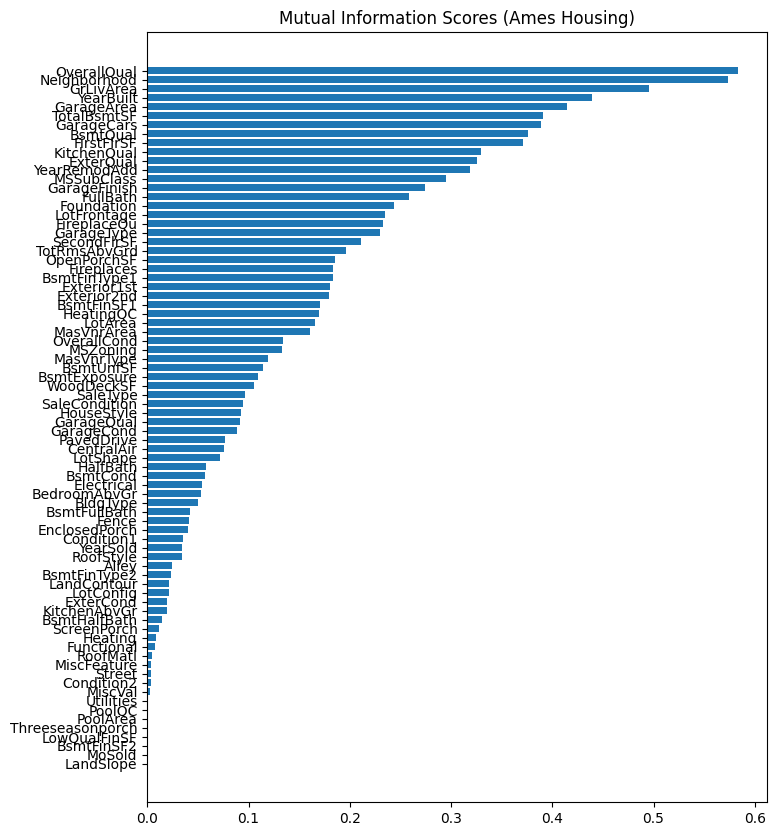

In [11]:
#Visualize MI scores
scores=mi_scores.sort_values()
plt.figure(figsize=(8,10))
plt.barh(range(len(scores)),scores)
plt.yticks(range(len(scores)),scores.index)
plt.title("Mutual Information Scores (Ames Housing)")
plt.show()

In [12]:
#Select Top-K features
top_features=mi_scores.head(10).index
X_selected=X[top_features]

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

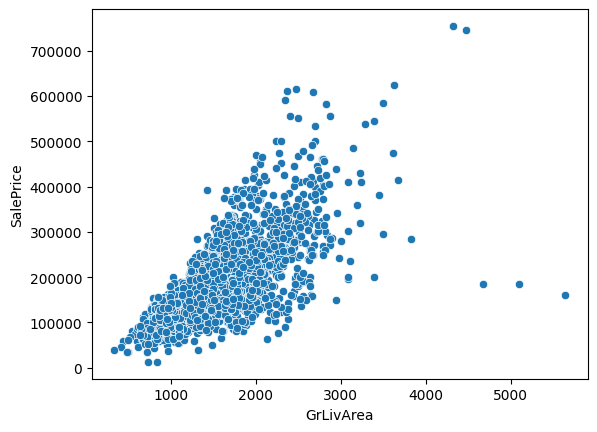

In [13]:
import seaborn as sns
sns.scatterplot(x=df["GrLivArea"],y=df["SalePrice"])